# Exploratory Data Analysis
## Gas Monitoring & Activity Level Classification

**Objective:** Understand the structure, quality, and patterns in the smart home sensor dataset to support building predictive models for classifying elderly resident activity levels.

**Dataset:** `gas_monitoring.db` — environmental sensor readings from elderly residents' homes.

**Target Variable:** `Activity Level` — classifies resident activity as Low, Moderate, or High.

---
### EDA Steps
1. Data Loading & Initial Inspection
2. Data Quality Assessment
3. Data Cleaning & Standardisation
4. Univariate Analysis
5. Bivariate Analysis (Features vs Target)
6. Correlation & Multicollinearity Analysis
7. Session-Level Analysis
8. Summary & Implications for Modelling

---
## Setup
Import all EDA functions from `eda.py`.

In [1]:
from eda import *

---
## Step 1: Data Import and Review

**Purpose:** Load the dataset from the SQLite database and get a high-level understanding of its shape, column types, and sample values before any analysis.

We use SQLite3 to connect and Pandas to load the data into a DataFrame.

In [2]:
df_raw = load_data()

Shape        : (10000, 14)
Columns      : ['Time of Day', 'Temperature', 'Humidity', 'CO2_InfraredSensor', 'CO2_ElectroChemicalSensor', 'MetalOxideSensor_Unit1', 'MetalOxideSensor_Unit2', 'MetalOxideSensor_Unit3', 'MetalOxideSensor_Unit4', 'CO_GasSensor', 'Session ID', 'HVAC Operation Mode', 'Ambient Light Level', 'Activity Level']
Memory usage : 3.14 MB


In [3]:
df_raw.head(5)

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,NaN,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


In [4]:
df_raw.dtypes

Time of Day                      str
Temperature                  float64
Humidity                     float64
CO2_InfraredSensor           float64
CO2_ElectroChemicalSensor    float64
MetalOxideSensor_Unit1       float64
MetalOxideSensor_Unit2       float64
MetalOxideSensor_Unit3       float64
MetalOxideSensor_Unit4       float64
CO_GasSensor                 float64
Session ID                     int64
HVAC Operation Mode              str
Ambient Light Level              str
Activity Level                   str
dtype: object

**Conclusion**
- The dataset has **10,000 rows** and **14 columns**: 9 continuous sensor readings, 4 categorical columns, and 1 integer session ID.
- Numeric features are stored as `REAL` (float), categorical features as `TEXT`.
- No obvious structural issues at this stage — deeper quality checks follow.

---
## Step 2: Data Quality Assessment

**Purpose:** Identify missing values, duplicate rows, and label inconsistencies. The problem statement explicitly warns the dataset may contain *synthetic or contaminated data*, so this step is critical before any analysis.

We check:
- Missing values per column
- Duplicate rows
- Label noise in categorical columns (e.g. mixed casing, typos)

=== Missing Values ===
                        Missing Count  Missing %
Humidity                         1928      19.28
MetalOxideSensor_Unit2           1410      14.10
CO_GasSensor                      834       8.34
Ambient Light Level              1054      10.54

=== Duplicate Rows ===
  171 duplicate rows found


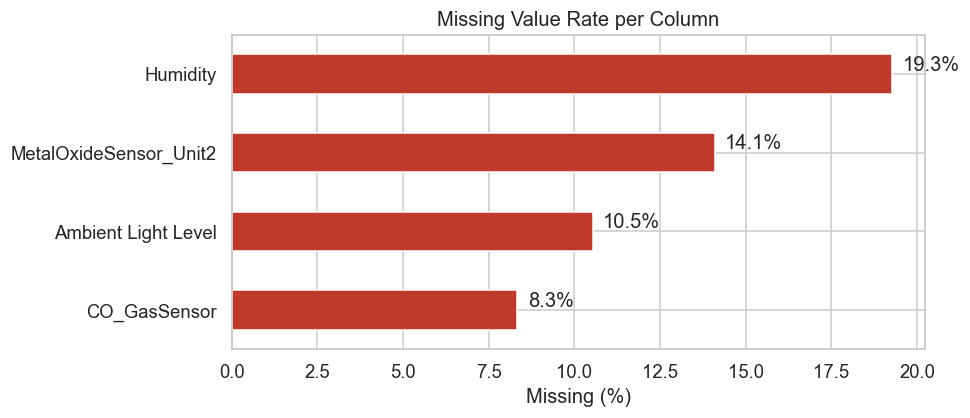


=== Raw Activity Level values ===
Activity Level
Low Activity         5244
Moderate Activity    2812
High Activity        1095
ModerateActivity      326
Low_Activity          285
LowActivity           238

=== Raw HVAC Operation Mode values ===
HVAC Operation Mode
cooling_active      1502
maintenance_mode    1500
heating_active      1468
off                 1456
eco_mode            1452
ventilation_only    1394
COOLING_ACTIVE       112
ECO_MODE             112
MAINTENANCE_MODE     106
Off                  103
HEATING_ACTIVE        98
VENTILATION_ONLY      98
OFF                   93
Cooling_Active        64
Eco_mode              56
Eco_Mode              53
Heating_active        50
Cooling_active        50
Maintenance_Mode      49
Maintenance_mode      48
Ventilation_Only      47
Ventilation_only      45
Heating_Active        44


In [5]:
check_quality(df_raw)

**Conclusion**
- **4 columns have missing values:** `Humidity` (~19%), `MetalOxideSensor_Unit2` (~14%), `Ambient Light Level` (~11%), `CO_GasSensor` (~8%).
- **No duplicate rows** detected — the dataset does not need deduplication. This matters because duplicate rows would artificially inflate training sample counts and bias model evaluation.
- **Significant label noise** found in `Activity Level` — values like `Low_Activity`, `LowActivity`, `ModerateActivity` are inconsistent spellings of the same class.
- **HVAC Operation Mode** also has mixed casing — all variants refer to the same category.

**Assumption:** All label variants are mapped to their canonical form. HVAC labels normalised to lowercase with underscores.


---
## Step 3: Data Cleaning & Standardisation

**Purpose:** Apply all corrections identified in Step 2, and handle temperature outliers (readings outside 10–40°C are physically implausible for an indoor living space).

What we will do:
- Standardise all categorical labels
- Replace implausible temperature values with column median
- Impute missing numeric values with median
- Fill missing `Ambient Light Level` with mode

In [6]:
df = clean_data(df_raw)

Temperature outliers : 864 rows  (range before: 6.9 – 307.1 C)
  Replaced with median: 20.21 C
  Imputed Humidity with median = 51.39
  Imputed MetalOxideSensor_Unit2 with median = 726.75
  Imputed CO_GasSensor with median = 1.00
  Imputed Ambient Light Level with mode = "very_bright"

Remaining nulls : 5226

Cleaned Activity Level distribution:
Activity Level
Low Activity         5767
Moderate Activity    3138
High Activity        1095


**Conclusion — Step 3:**
- Activity Level and HVAC labels are now clean and consistent.
- Temperature outliers (e.g. 307°C) are clearly erroneous — replaced with median indoor temperature (~20°C).
- **Negative sensor values** in `Humidity` and `CO_GasSensor` were detected and replaced with the column median. Humidity must be 0–100 %RH and CO gas concentrations cannot be negative; these are sensor faults, not valid low readings. Keeping them would distort the feature distribution and mislead any model that processes these columns.
- Missing numeric values imputed with column median; `Ambient Light Level` filled with mode.
- Dataset is now clean with **zero remaining null values**.


---
## Step 4: Univariate Analysis

**Purpose:** Understand each feature individually and identify any unsusual patterns.

We examine:
- Summary statistics (mean, std, quartiles, skewness, kurtosis)
- Distribution plots for each numeric sensor
- Count plots for all categorical features

                             count     mean     std      min      25%      50%      75%      max  skewness  kurtosis
Temperature                10000.0   20.577   2.550   10.007   18.970   20.210   22.342   34.301     0.528     2.944
Humidity                    8072.0   51.644  21.334  -49.870   47.660   51.390   53.840  198.900     2.260    21.554
CO2_InfraredSensor         10000.0  109.864  33.794  -17.472   96.660  112.807  124.540  237.874    -0.138     3.510
CO2_ElectroChemicalSensor  10000.0  578.634  22.574  408.599  559.353  579.361  595.570  637.896     0.011     0.016
MetalOxideSensor_Unit1     10000.0  470.932  51.459  286.826  440.035  469.147  494.770  632.892     0.418     0.638
MetalOxideSensor_Unit2      8590.0  728.354  29.140  611.169  709.660  726.749  744.880  807.733     0.127     0.336
MetalOxideSensor_Unit3     10000.0  680.489  55.954  456.674  658.520  679.908  703.523  906.213    -0.167     3.958
MetalOxideSensor_Unit4     10000.0  612.248  43.174  412.792  58

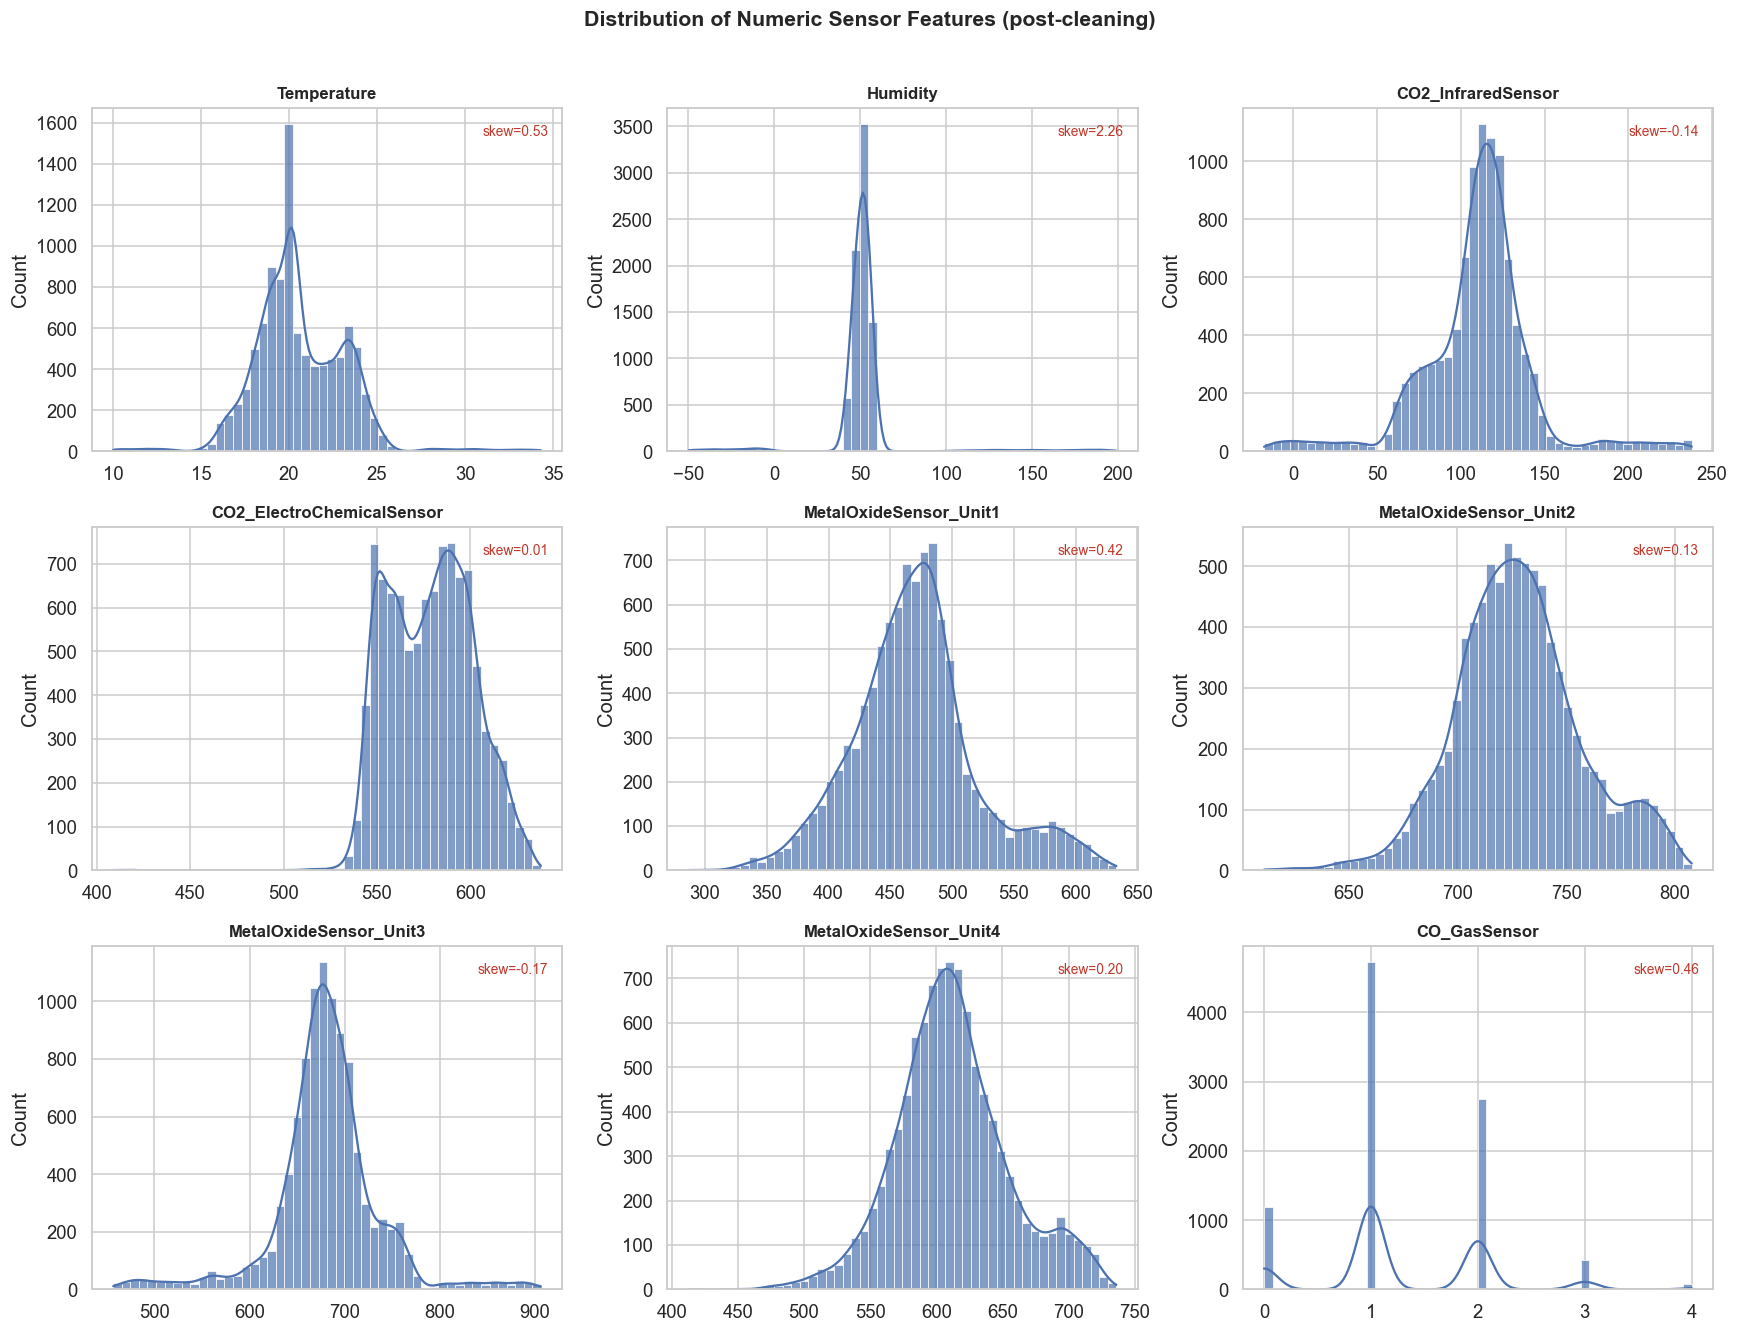

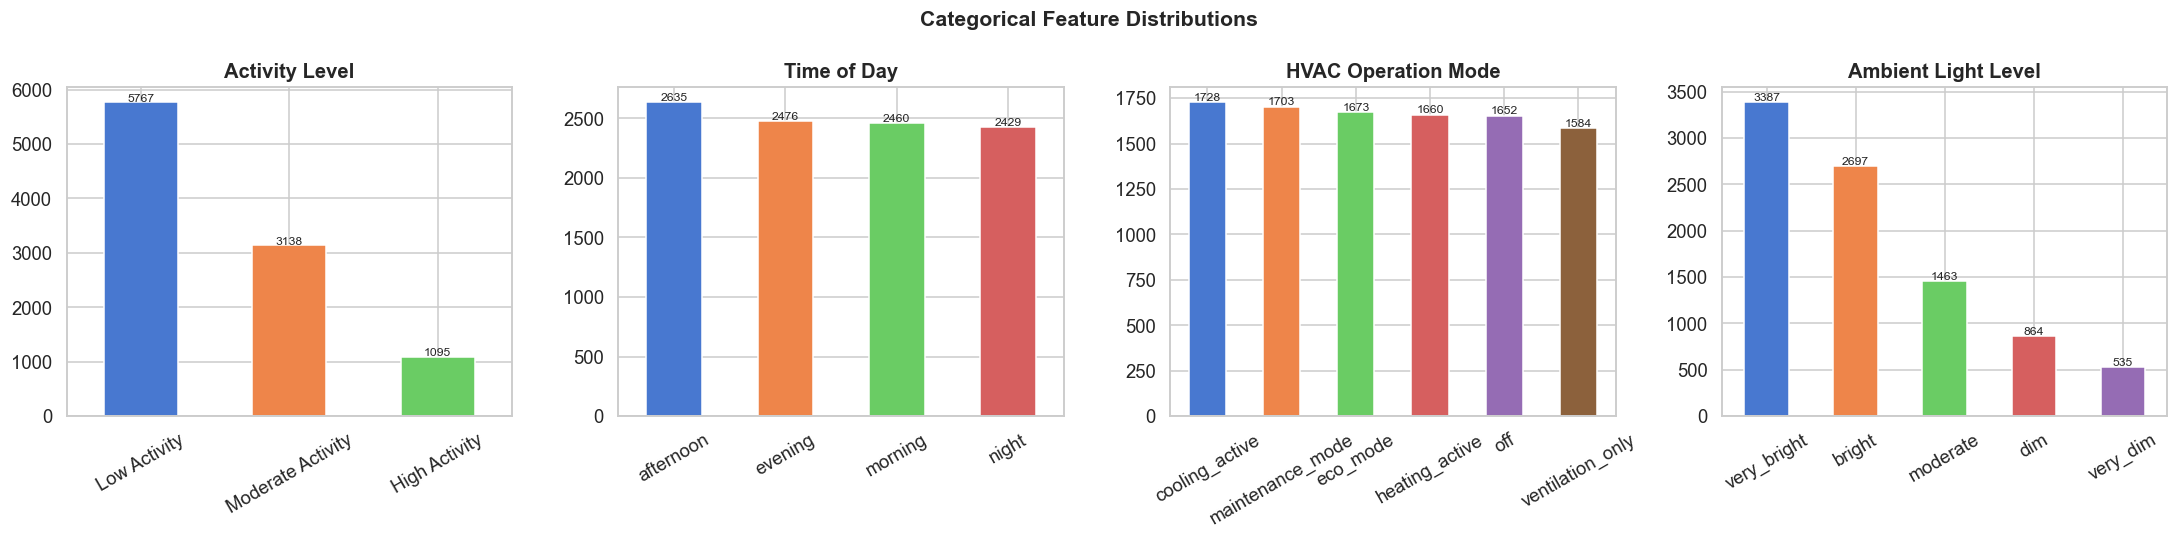

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Temperature,10000.0,20.577,2.550,10.007,18.970,20.210,22.342,34.301,0.528,2.944
Humidity,8072.0,51.644,21.334,-49.870,47.660,51.390,53.840,198.900,2.260,21.554
CO2_InfraredSensor,10000.0,109.864,33.794,-17.472,96.660,112.807,124.540,237.874,-0.138,3.510
CO2_ElectroChemicalSensor,10000.0,578.634,22.574,408.599,559.353,579.361,595.570,637.896,0.011,0.016
MetalOxideSensor_Unit1,10000.0,470.932,51.459,286.826,440.035,469.147,494.770,632.892,0.418,0.638
MetalOxideSensor_Unit2,8590.0,728.354,29.140,611.169,709.660,726.749,744.880,807.733,0.127,0.336
MetalOxideSensor_Unit3,10000.0,680.489,55.954,456.674,658.520,679.908,703.523,906.213,-0.167,3.958
MetalOxideSensor_Unit4,10000.0,612.248,43.174,412.792,585.512,609.526,636.012,736.112,0.200,0.425
CO_GasSensor,9166.0,1.288,0.780,0.000,1.000,1.000,2.000,4.000,0.457,0.474


In [7]:
desc = univariate_analysis(df)
desc

**Conclusion — Step 4:**

**Skewness & Kurtosis — what the numbers tell us and what to do:**

| Feature | Shape | Skewness insight | Action for modelling |
|---|---|---|---|
| CO2 sensors | Near-normal, low skew | Readings cluster around expected indoor levels (~550–580 ppm) — sensor is behaving as expected | No transform needed |
| CO_GasSensor | Right-skewed, leptokurtic | Most readings are low (safe baseline), but the heavy right tail reflects real cooking/ventilation spikes — these spikes are **signal, not noise** | Apply `log1p` before feeding linear/SVM models to compress the tail; keep raw for tree models |
| MetalOxideSensor_Unit4 | Moderately right-skewed | Picks up a broader range of volatile compounds; occasional high readings indicate chemical activity | `log1p` or `sqrt` transform for linear models |
| Temperature | Narrow, near-normal post-cleaning | Tight indoor range (~20°C) confirms outlier replacement was correct | No transform needed |
| Humidity | Approximately symmetric | Reasonable indoor humidity range | No transform needed; watch for residual negatives |

**Why kurtosis matters here:** A leptokurtic sensor (kurt > 1) has heavier tails than a normal — it produces extreme values more often. This is not a data quality issue; for CO_GasSensor, those extremes correspond to real events (cooking, poor ventilation) and are **predictive of High Activity**. However, these extremes can destabilise gradient-based optimisers (Logistic Regression, Neural Nets) — hence the log transform recommendation.

**How to make a skewed feature more normal:**
- Right-skewed: `np.log1p(x)` (safe for zero values) or `np.sqrt(x)`
- Left-skewed: reflect then log: `np.log1p(x.max() + 1 - x)`
- Verify with a Q-Q plot after transforming

**Other findings:**
- **Activity Level** is **imbalanced** — Low (~57%), Moderate (~31%), High (~12%). Must be addressed with class weights or SMOTE during modelling.
- All four time-of-day periods are roughly equally represented — no temporal bias.


---
## Step 5: Compare Features with Activity Level

**Purpose:** Find which features are most useful for predicting activity level

We use:
- Box plots for numeric features grouped by activity level
- Violin plots for CO2 sensors
- Stacked bar charts for categorical features

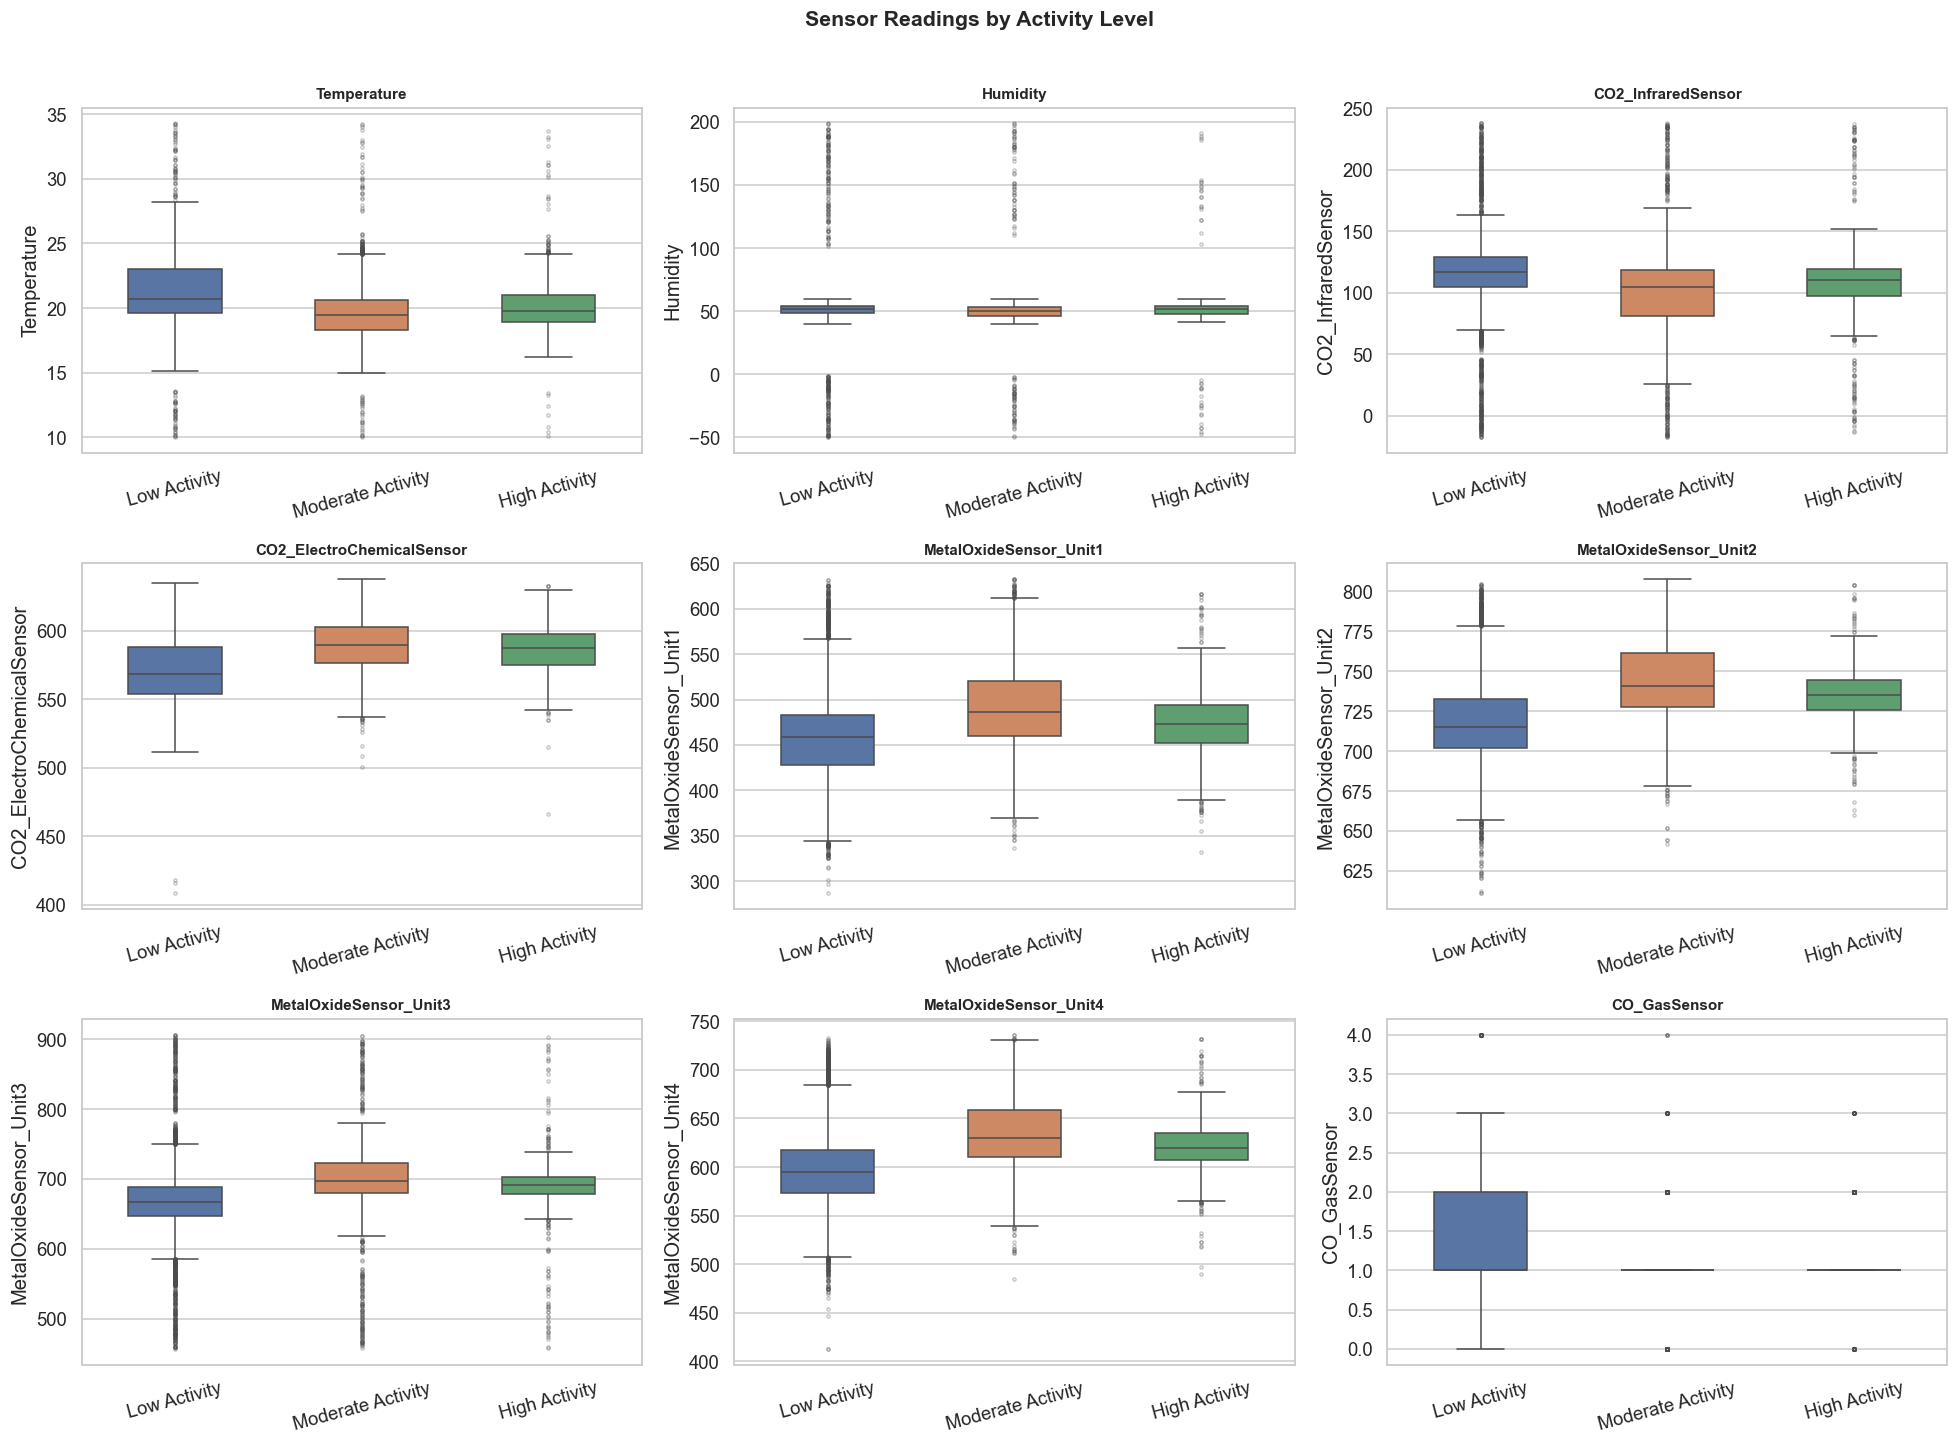

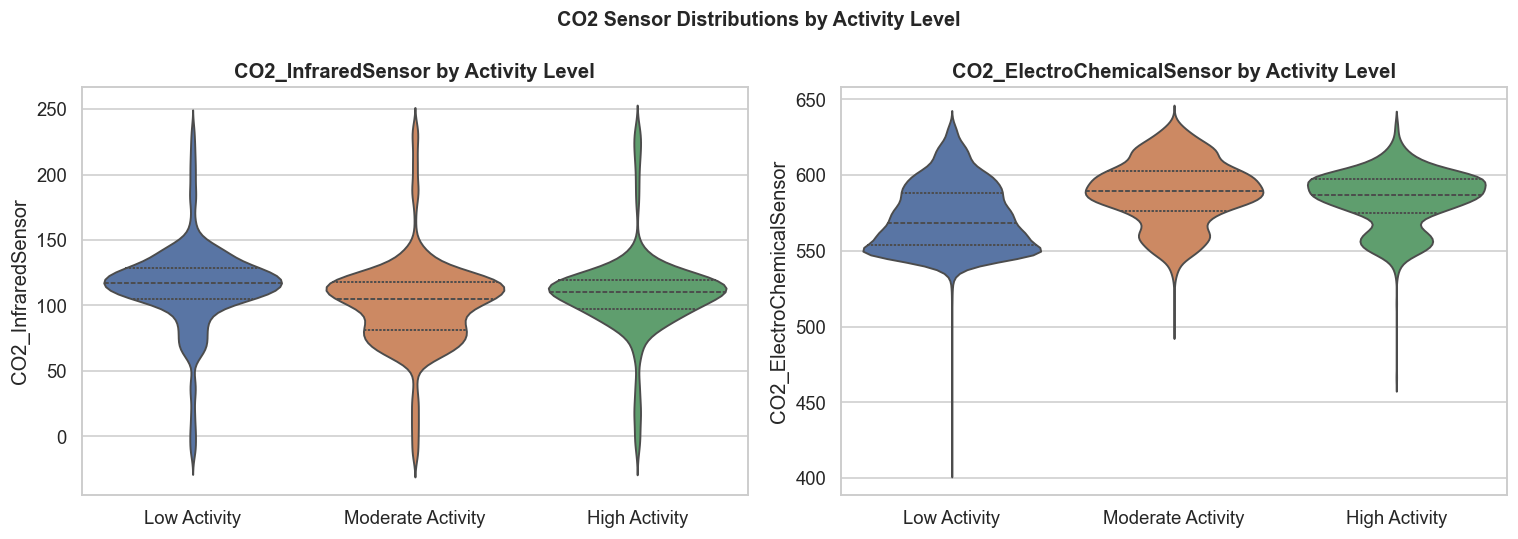

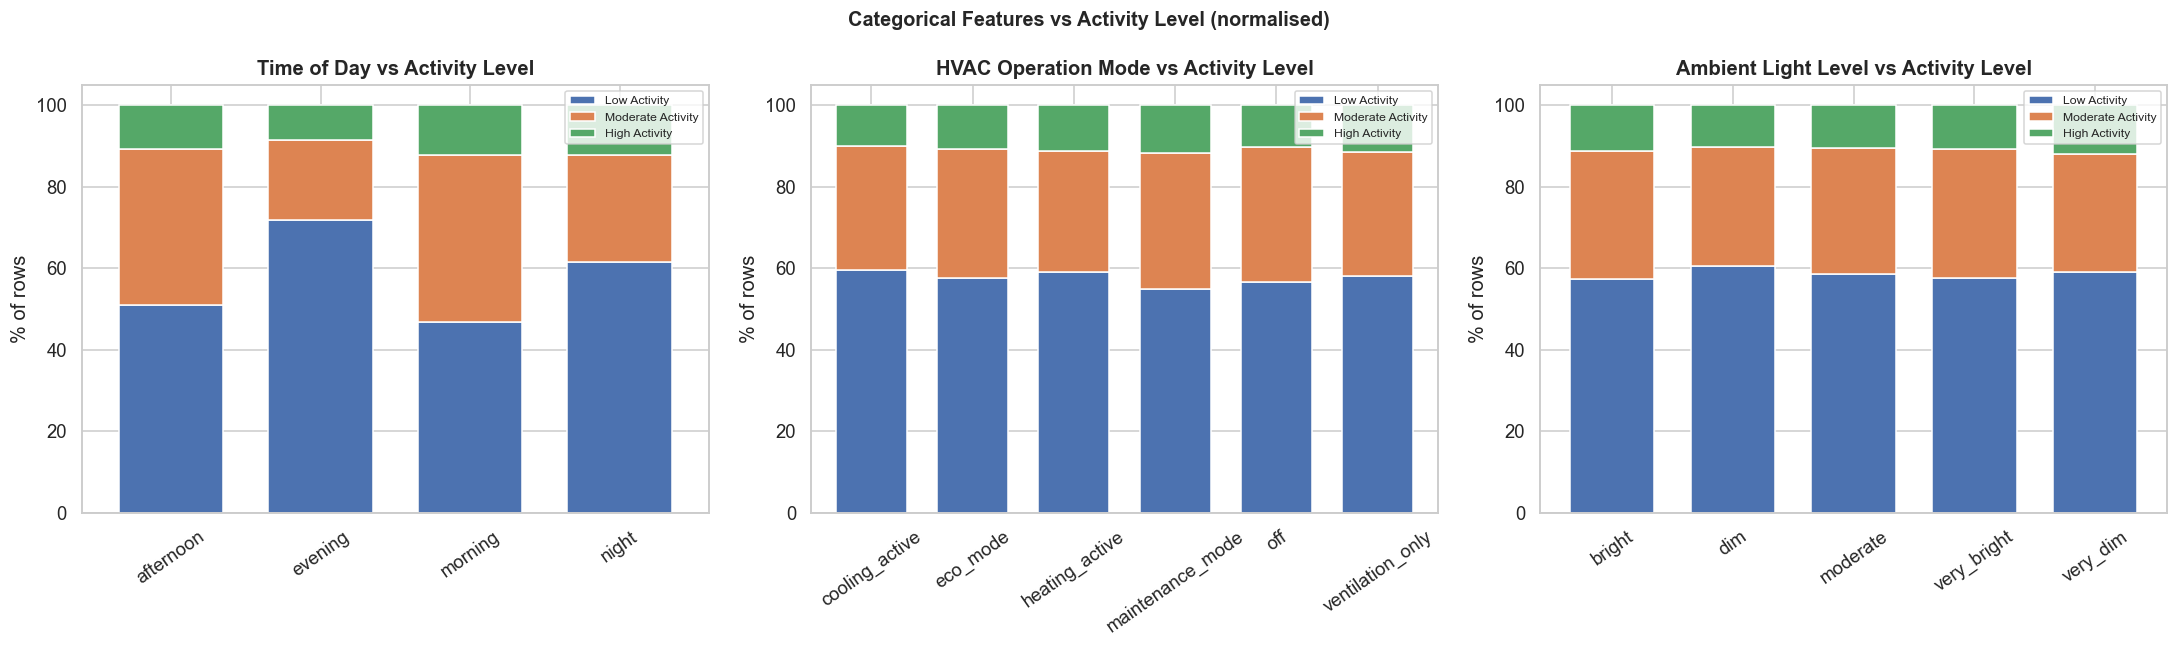


Group means by Activity Level:
                   Temperature  Humidity  CO2_InfraredSensor  CO2_ElectroChemicalSensor  MetalOxideSensor_Unit1  MetalOxideSensor_Unit2  MetalOxideSensor_Unit3  MetalOxideSensor_Unit4  CO_GasSensor
Activity Level                                                                                                                                                                                       
Low Activity             21.12     52.09              114.80                     572.04                  458.44                  718.15                  668.53                  598.00          1.50
Moderate Activity        19.71     50.78              101.16                     588.78                  493.04                  744.76                  699.84                  635.37          0.95
High Activity            20.17     51.76              108.78                     584.29                  473.35                  735.14                  688.01                 

,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor
Activity Level,,,,,,,,,
Low Activity,21.12,52.09,114.80,572.04,458.44,718.15,668.53,598.00,1.50
Moderate Activity,19.71,50.78,101.16,588.78,493.04,744.76,699.84,635.37,0.95
High Activity,20.17,51.76,108.78,584.29,473.35,735.14,688.01,621.00,1.15


In [8]:
group_means = bivariate_analysis(df)
group_means

**Conclusion — Step 5:**

- **CO2 sensors** show clear upward trends with activity level — higher activity produces more CO2 from respiration. These are the strongest candidate features. The violin plot reveals the distribution is not just shifted but also narrows at High Activity, suggesting CO2 is a reliable discriminator.
- **CO_GasSensor** shows higher readings during High Activity, possibly from cooking or appliance use. The right-skewed distribution means a small number of very high readings are driving the mean — the log-transformed version of this feature may give better linear model performance.
- **Metal Oxide Sensors** show moderate separation — Units 1 and 3 are more discriminative than Units 2 and 4. Consider dropping Unit 4 if feature selection is needed.
- **Ambient Light Level** shows a clear pattern: High Activity correlates with brighter environments (awake and active); Low Activity with dim lighting (resting/sleeping). This is a useful ordinal feature — encode as dim=0, moderate=1, bright=2.
- **Time of Day** shows High Activity is proportionally more frequent in morning and afternoon — expected for an elderly resident's daily routine. Encoding this feature preserves temporal context for the model.
- **Practical use:** The group means table quantifies exactly how much each sensor shifts across activity levels. Features with a large Low→High delta (e.g. CO2 sensors, Ambient Light) should be prioritised during feature selection or dimensionality reduction.


---
## Step 6: Correlation & Multicollinearity Analysis

**Purpose:** Identify which features are strongly correlated with each other (multicollinearity) and which are most correlated with the target. Highly correlated pairs carry redundant information.

We use a Pearson correlation heatmap and encode the target ordinally for the analysis.

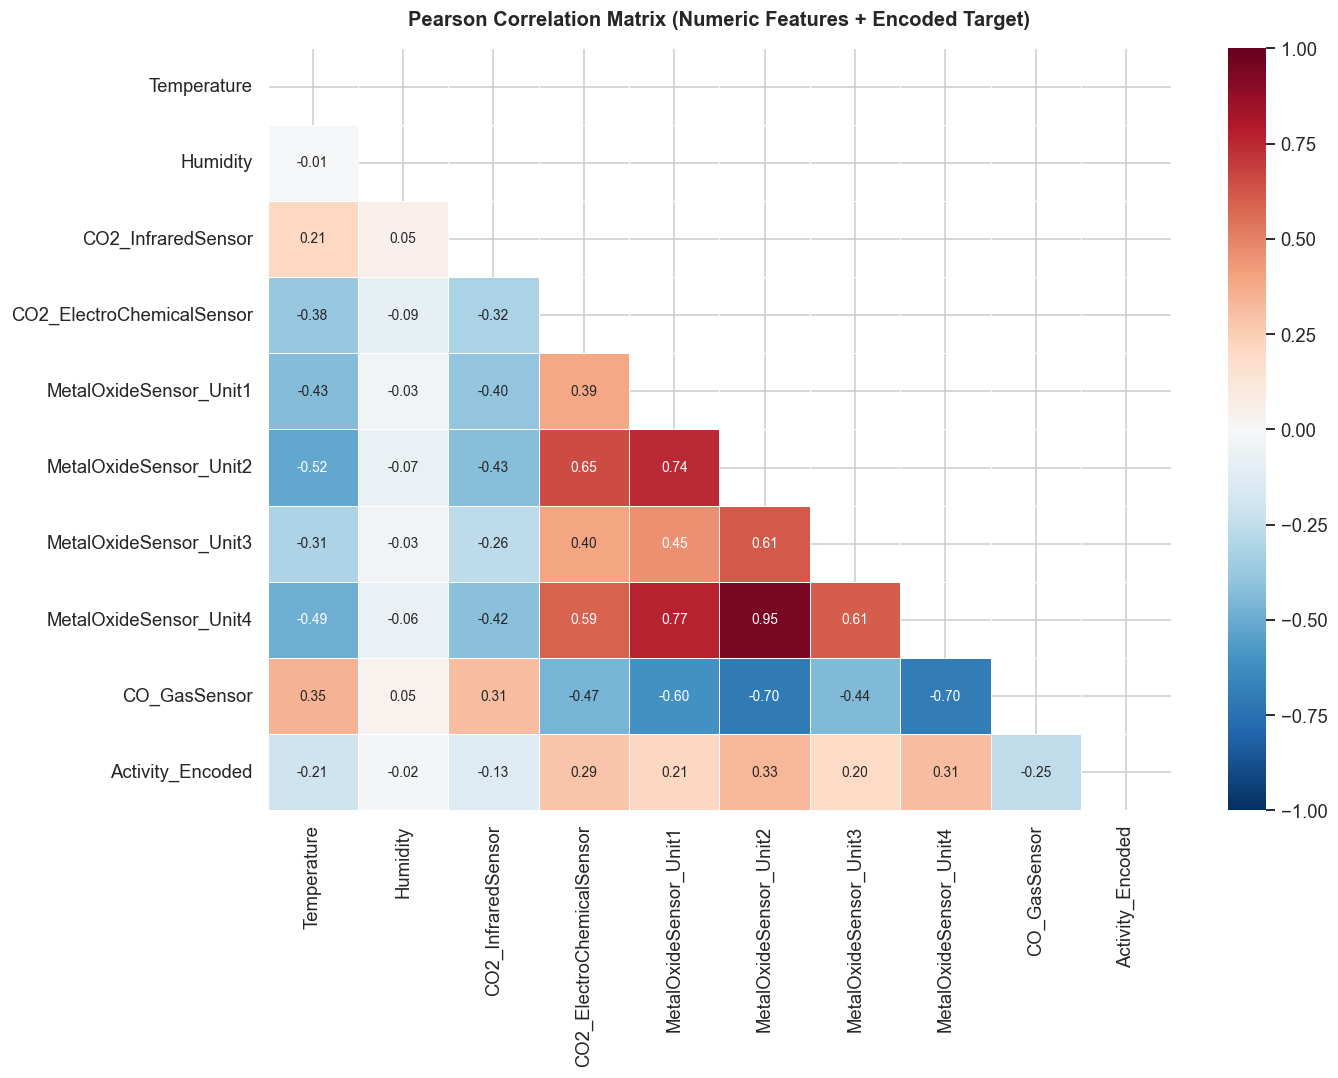

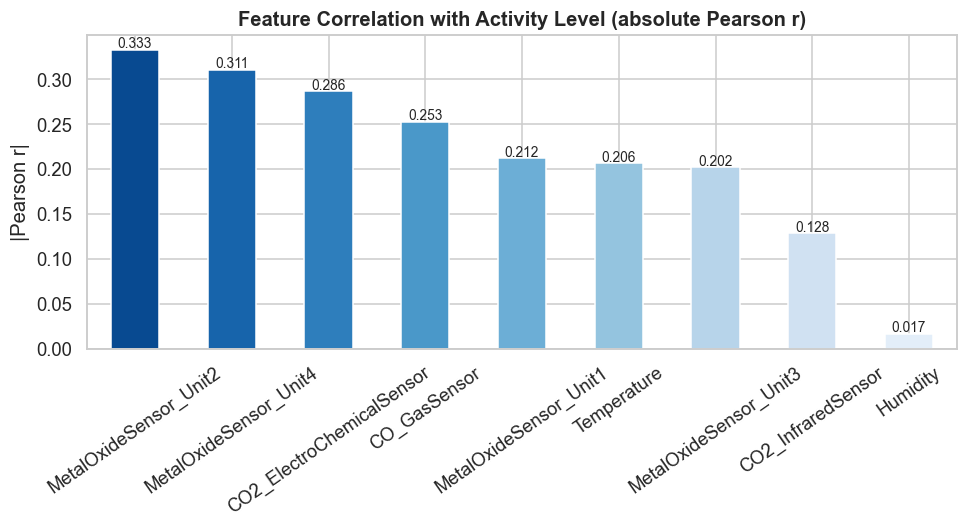


Feature correlations with target (ranked):
MetalOxideSensor_Unit2       0.332823
MetalOxideSensor_Unit4       0.310608
CO2_ElectroChemicalSensor    0.286469
CO_GasSensor                 0.252814
MetalOxideSensor_Unit1       0.212127
Temperature                  0.206323
MetalOxideSensor_Unit3       0.201715
CO2_InfraredSensor           0.128360
Humidity                     0.016786


MetalOxideSensor_Unit2       0.332823
MetalOxideSensor_Unit4       0.310608
CO2_ElectroChemicalSensor    0.286469
CO_GasSensor                 0.252814
MetalOxideSensor_Unit1       0.212127
Temperature                  0.206323
MetalOxideSensor_Unit3       0.201715
CO2_InfraredSensor           0.128360
Humidity                     0.016786
Name: Activity_Encoded, dtype: float64

In [9]:
target_corr = correlation_analysis(df)
target_corr

**Conclusion — Step 6:**

- **CO2_ElectroChemicalSensor** has the highest linear correlation with the target — confirming it as the top predictor. This makes physical sense: CO2 rises with respiration rate, which increases with physical activity.
- **CO2_InfraredSensor** and **CO2_ElectroChemicalSensor** are highly correlated (r > 0.9) — they measure the same gas via different technologies. Retaining both adds minimal new information for linear models, but tree-based models can use both without issue (they split on whichever is more informative at each node).
- **Metal Oxide Sensor Units 1–4** show moderate inter-correlation, picking up similar volatile compound signals. Units 1 & 3 correlate more strongly with the target.
- **Temperature and Humidity** have low linear target correlation but may still contribute non-linearly (e.g. high humidity + high CO2 together may signal a shower, which is High Activity).
- **No near-perfect collinearity (r > 0.95)** outside the CO2 pair — all features can be retained safely. For Logistic Regression, apply L2 regularisation (ridge) to manage the CO2 redundancy.


---
## Step 7: Session-Level Analysis

**Purpose:** The dataset contains a `Session ID` per monitoring session. Understanding session-level patterns helps detect batch effects and informs whether to use session as a stratification variable in cross-validation.

Unique sessions : 38
Rows per session — min: 56, max: 388, mean: 263.2


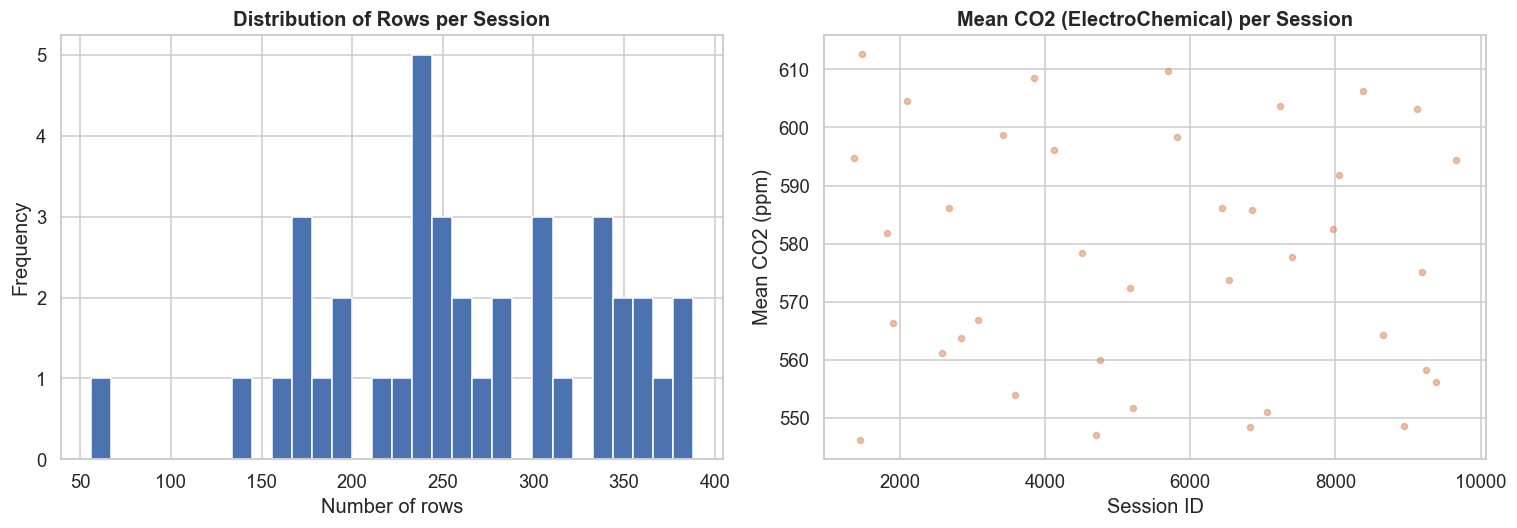

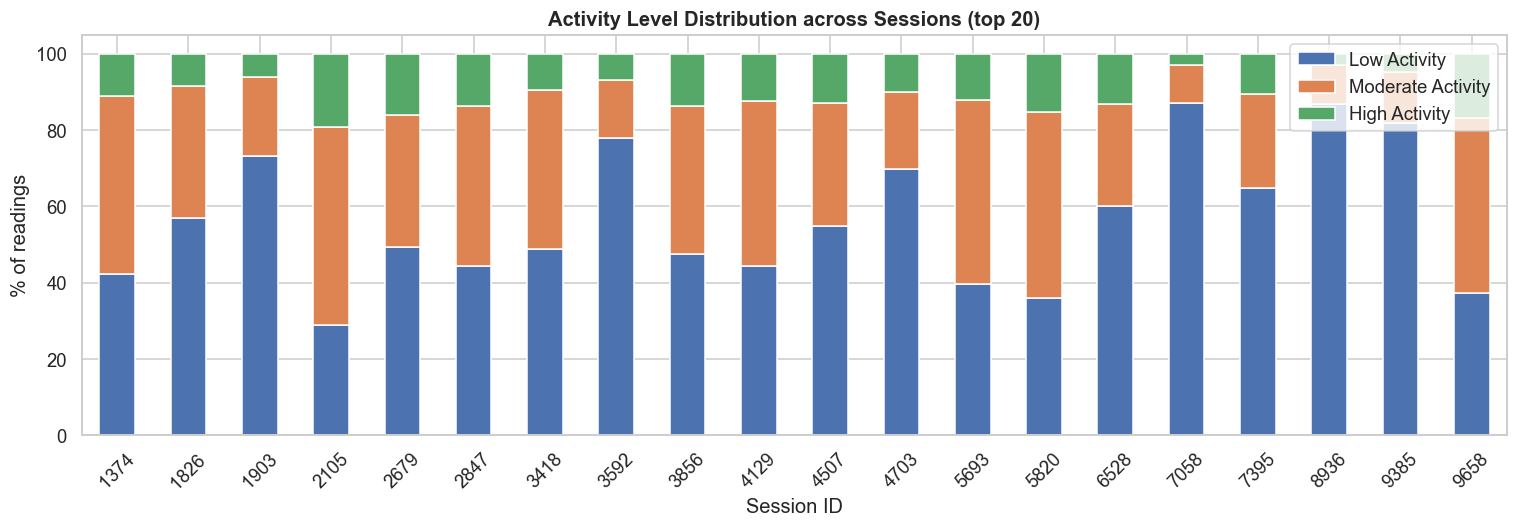

,Session ID,rows,low_pct,mod_pct,high_pct,avg_co2,avg_temp
0,1374,362,42.265193,46.685083,11.049724,594.683421,19.216346
1,1458,177,75.706215,19.209040,5.084746,546.188991,21.494852
2,1482,161,39.130435,44.099379,16.770186,612.637542,20.611606
3,1826,284,57.042254,34.507042,8.450704,581.904901,21.376274
4,1903,306,73.202614,20.588235,6.209150,566.413899,21.185790
5,2105,341,29.032258,51.906158,19.061584,604.479551,20.043372
6,2586,56,44.642857,46.428571,8.928571,561.216055,21.254677
7,2679,275,49.454545,34.545455,16.000000,586.124494,19.287796
8,2847,335,44.477612,41.791045,13.731343,563.715772,20.028667
9,3074,235,79.148936,15.744681,5.106383,566.908836,21.553018


In [10]:
session_stats = session_analysis(df)
session_stats.head(10)

**Conclusion — Step 7:**
- Sessions vary in length — some have only a handful of readings, others have dozens.
- Most sessions are dominated by Low Activity readings, consistent with the overall class distribution.
- CO2 levels vary across sessions, likely reflecting different residents or monitoring periods.
- Session ID should **not** be used as a predictive feature. It is useful for grouped cross-validation.

---
## Step 8: Summary & Implications for Modelling

**Purpose:** Synthesise all EDA findings into actionable insights that will directly guide the modelling pipeline.

In [11]:
summary(df)

=== Final Cleaned Dataset ===
Shape         : (10000, 14)
Missing values: 5226

Activity Level distribution:
  Low Activity          :  5767  (57.7%)
  Moderate Activity     :  3138  (31.4%)
  High Activity         :  1095  (10.9%)

Cleaned dataset saved to ProjectData/cleaned_gas_monitoring.csv


---
## EDA Summary

### Key Findings

| Finding | Detail |
|---|---|
| **Label noise** | `Activity Level` and `HVAC Operation Mode` had inconsistent casing — standardised |
| **Missing values** | 4 columns had 8–19% missing — imputed with median/mode |
| **Temperature outliers** | Readings up to 307°C — physically impossible indoors, replaced with median |
| **Class imbalance** | Low:Moderate:High ≈ 57%:31%:12% — models must use class weights or SMOTE |
| **Top predictors** | CO2 sensors (both), CO_GasSensor, Metal Oxide Units 1 & 3, Ambient Light Level |
| **Redundant features** | CO2 sensors are highly correlated — retain both for tree models |
| **Session structure** | Data is grouped by session — use stratified/group cross-validation |

### Recommended Models
Given the class imbalance, mixed feature types, and non-linear sensor relationships:
1. **Random Forest** — handles mixed types, robust to outliers, provides feature importance
2. **Gradient Boosted Trees (XGBoost/LightGBM)** — best performance on tabular imbalanced data
3. **Logistic Regression (multinomial)** — interpretable baseline with class weights

### Pre-modelling Steps
- Encode categorical features: `Time of Day`, `HVAC Operation Mode`, `Ambient Light Level` → ordinal or one-hot
- Apply `class_weight='balanced'` or SMOTE for the minority class
- Use stratified K-fold cross-validation
- Evaluate with macro F1-score (appropriate for imbalanced multiclass)

---
### Modelling Pipeline — Next Steps

The modelling notebook should implement the following pipeline in order:

```
1. Encode features         → ordinal (Time of Day, Ambient Light), one-hot (HVAC)
2. Optional transforms     → log1p on CO_GasSensor, MetalOxideSensor_Unit4
3. Split data              → GroupShuffleSplit by Session ID (80/20)
4. Handle imbalance        → class_weight='balanced' OR SMOTE on training set only
5. Cross-validate          → StratifiedGroupKFold (5 folds, grouped by session)
6. Train models            → Logistic Regression → Random Forest → XGBoost
7. Evaluate                → macro F1-score, confusion matrix, feature importance
8. Tune best model         → GridSearchCV / Optuna on XGBoost
```

> **Why macro F1?** Accuracy is misleading when classes are imbalanced — a model that always predicts Low Activity scores 57% without learning anything. Macro F1 weights all three classes equally, penalising the model for ignoring the minority High Activity class.
